**<center><font size=8>Health Insurance Premium Prediction</center></font>**

<center><p float="center">
 <img src="https://images.news18.com/ibnlive/uploads/2025/09/zero-gst-health-and-life-insurance-premiums-2025-09-cf92e107d27696f1195fd48fcb2aabd9-16x9.png?impolicy=website&width=400&height=225" width="720"/>
</p></center>



  

## **Problem Statement**

The goal of this project is to build a predictive model that can accurately estimate medical insurance charges based on various demographic and health-related factors. By understanding the key drivers of insurance costs, we can help insurance companies with pricing strategies and assist individuals in anticipating their healthcare expenses. The dataset contains information such as age, sex, BMI, number of children, smoking status, region, and corresponding medical charges.

In [1]:
# Import libraries for reading and manipulating data
import pandas as pd
# Import library for numerical operations
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import utilities for performance evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Import utilities for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

## **Loading the Dataset**


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
data = pd.read_csv('/content/drive/MyDrive/GenAI-Course/Health_Insurance/insurance_prediction.csv')

## **Data Overview**

First, let's get a general understanding of our dataset. This includes looking at the first few rows, checking data types, identifying missing values, and summarizing descriptive statistics.

In [4]:
# Display the first 5 rows of the dataset to get a glimpse of the data
display(data.head())

# Get a concise summary of the DataFrame, including data types and non-null values
print('\n--- Data Info ---')
data.info()

# Generate descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution
print('\n--- Descriptive Statistics ---')
display(data.describe())

# Check for any missing values in each column
print('\n--- Missing Values ---')
display(data.isnull().sum())

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Descriptive Statistics ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010



--- Missing Values ---


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## **Exploratory Data Analysis (EDA)**

EDA helps us understand the underlying patterns, relationships, and anomalies within the data. We'll perform both univariate and bivariate analyses.

### **Univariate Analysis**

Analyzing individual features to understand their distributions.

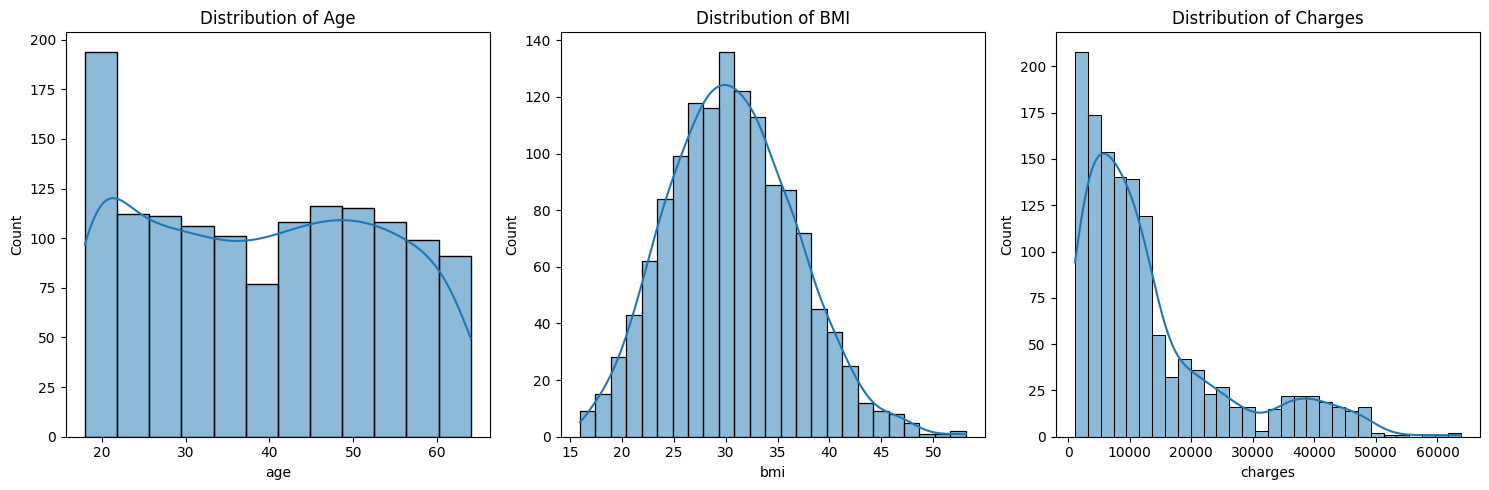

In [5]:
plt.figure(figsize=(15, 5))

# Distribution of 'age'
plt.subplot(1, 3, 1)
sns.histplot(data['age'], kde=True)
plt.title('Distribution of Age')

# Distribution of 'bmi'
plt.subplot(1, 3, 2)
sns.histplot(data['bmi'], kde=True)
plt.title('Distribution of BMI')

# Distribution of 'charges'
plt.subplot(1, 3, 3)
sns.histplot(data['charges'], kde=True)
plt.title('Distribution of Charges')

plt.tight_layout()
plt.show()

 Descriptive Statistics for Numerical Features

In [6]:
import numpy as np
# Display descriptive statistics for numerical features (age, bmi, children, charges)
print('--- Descriptive Statistics for Numerical Features ---')
numerical_cols = data.select_dtypes(include=np.number).columns
display(data[numerical_cols].describe())

--- Descriptive Statistics for Numerical Features ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


 Observations from Numerical Distributions:
*   **Age:** The distribution of age is fairly uniform, suggesting a good spread across different age groups.
*   **BMI:** The BMI distribution appears somewhat normal, with a slight right skew, indicating a concentration around the healthy to overweight range.
*   **Charges:** The distribution of charges is highly right-skewed, meaning most people have lower insurance costs, but a significant number have very high costs. This often indicates the presence of outliers or influential factors leading to high charges.

 **Distribution of 'sex' as a Pie Chart and Table**

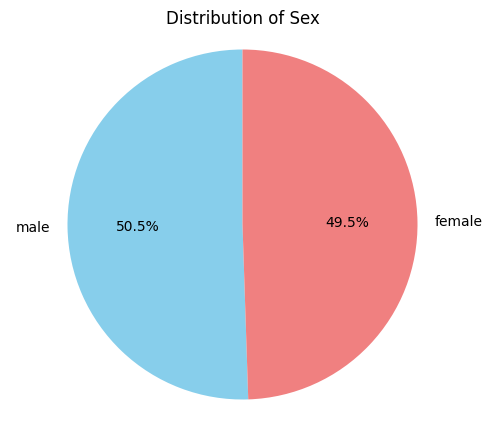


--- Counts of Sex ---


,count
sex,
male,676
female,662


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of 'sex' as a Pie Chart
sex_counts = data['sex'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Sex')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print('\n--- Counts of Sex ---')
display(sex_counts.to_frame())

 Distribution of 'smoker' as a Pie Chart and Table

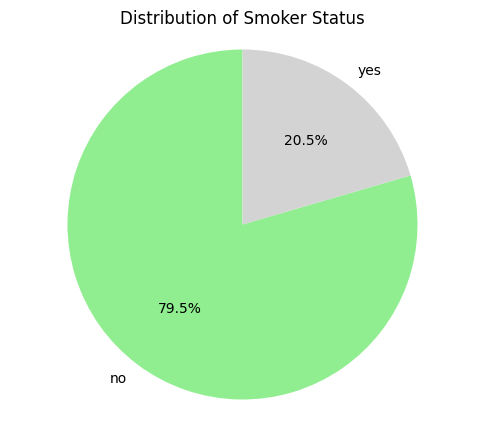


--- Counts of Smoker Status ---


,count
smoker,
no,1064
yes,274


In [8]:
# Distribution of 'smoker' as a Pie Chart
smoker_counts = data['smoker'].value_counts()

plt.figure(figsize=(6, 5))
plt.pie(smoker_counts, labels=smoker_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'lightgray'])
plt.title('Distribution of Smoker Status')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print('\n--- Counts of Smoker Status ---')
display(smoker_counts.to_frame())

 Distribution of 'region' as a Pie Chart and Table

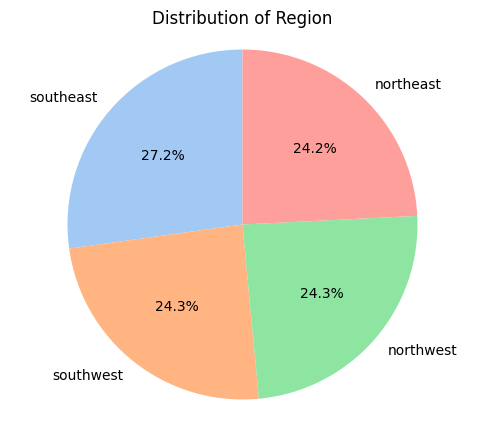


--- Counts of Region ---


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [9]:
# Distribution of 'region' as a Pie Chart
region_counts = data['region'].value_counts()

plt.figure(figsize=(6,5 ))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel')[0:4])
plt.title('Distribution of Region')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print('\n--- Counts of Region ---')
display(region_counts.to_frame())

### **Bivariate Analysis**

Analyzing relationships between features, especially with the target variable `charges`.

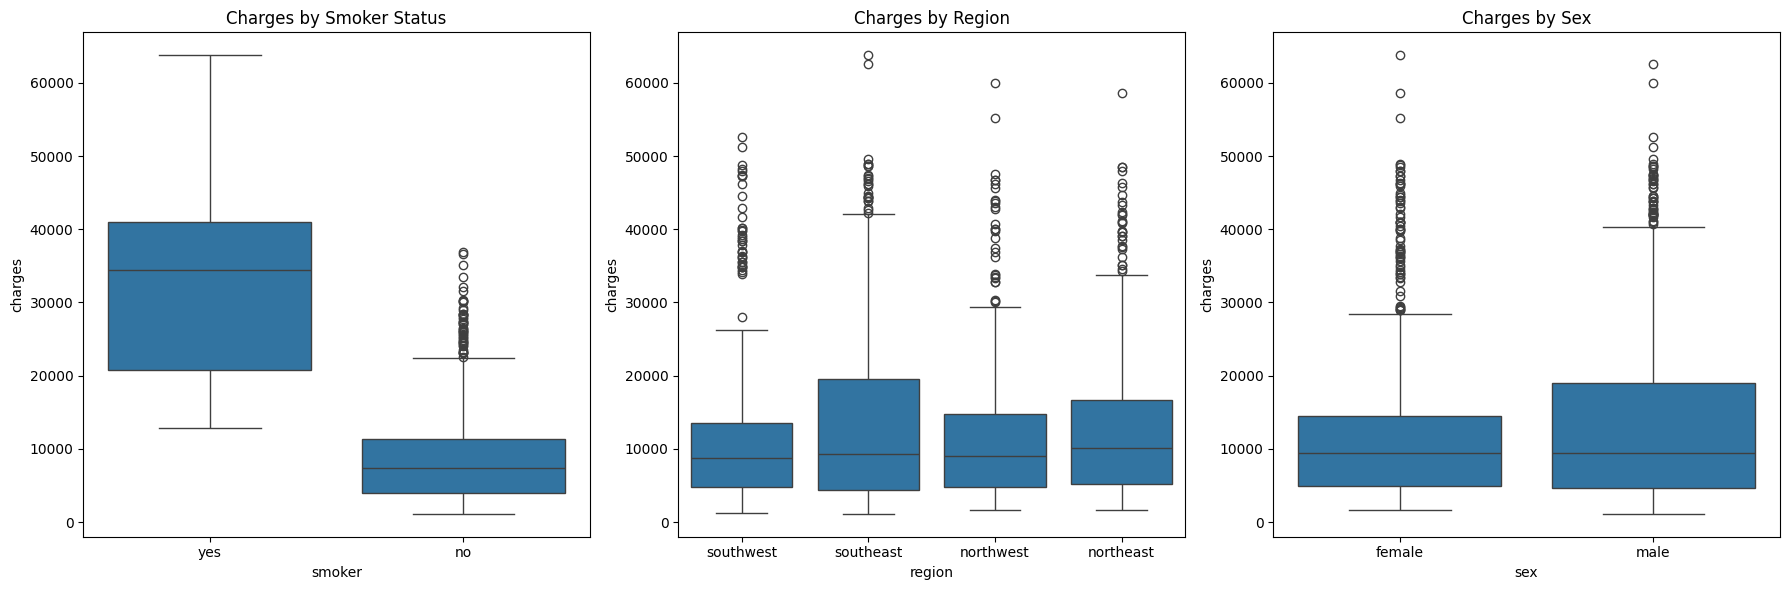

In [10]:
plt.figure(figsize=(18, 6))

# Charges by Smoker Status
plt.subplot(1, 3, 1)
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Charges by Smoker Status')

# Charges by Region
plt.subplot(1, 3, 2)
sns.boxplot(x='region', y='charges', data=data)
plt.title('Charges by Region')

# Charges by Sex
plt.subplot(1, 3, 3)
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Charges by Sex')

plt.tight_layout()
plt.show()

 Summary Statistics for Charges by Categorical Features

In [11]:
# Mean, Median, and Standard Deviation of Charges by Smoker Status
print('\n--- Charges by Smoker Status ---\n')
display(data.groupby('smoker')['charges'].agg(['mean', 'median', 'std']).reset_index())

# Mean, Median, and Standard Deviation of Charges by Region
print('\n--- Charges by Region ---\n')
display(data.groupby('region')['charges'].agg(['mean', 'median', 'std']).reset_index())

# Mean, Median, and Standard Deviation of Charges by Sex
print('\n--- Charges by Sex ---\n')
display(data.groupby('sex')['charges'].agg(['mean', 'median', 'std']).reset_index())


--- Charges by Smoker Status ---



,smoker,mean,median,std
0,no,8434.268298,7345.40530,5993.781819
1,yes,32050.231832,34456.34845,11541.547176



--- Charges by Region ---



,region,mean,median,std
0,northeast,13406.384516,10057.652025,11255.803066
1,northwest,12417.575374,8965.795750,11072.276928
2,southeast,14735.411438,9294.131950,13971.098589
3,southwest,12346.937377,8798.593000,11557.179101



--- Charges by Sex ---



,sex,mean,median,std
0,female,12569.578844,9412.96250,11128.703801
1,male,13956.751178,9369.61575,12971.025915


 Observations from Bivariate Analysis (Categorical vs. Charges):
*   **Smoker vs. Charges:** This is a very strong relationship. Smokers incur significantly higher medical charges than non-smokers.
*   **Region vs. Charges:** There are slight differences in charges across regions, with the southeast appearing to have slightly higher average charges, but the difference is not as pronounced as with smoking status.
*   **Sex vs. Charges:** There appears to be a minimal difference in charges between males and females, with males having a slightly higher median charge but also a wider spread for females.

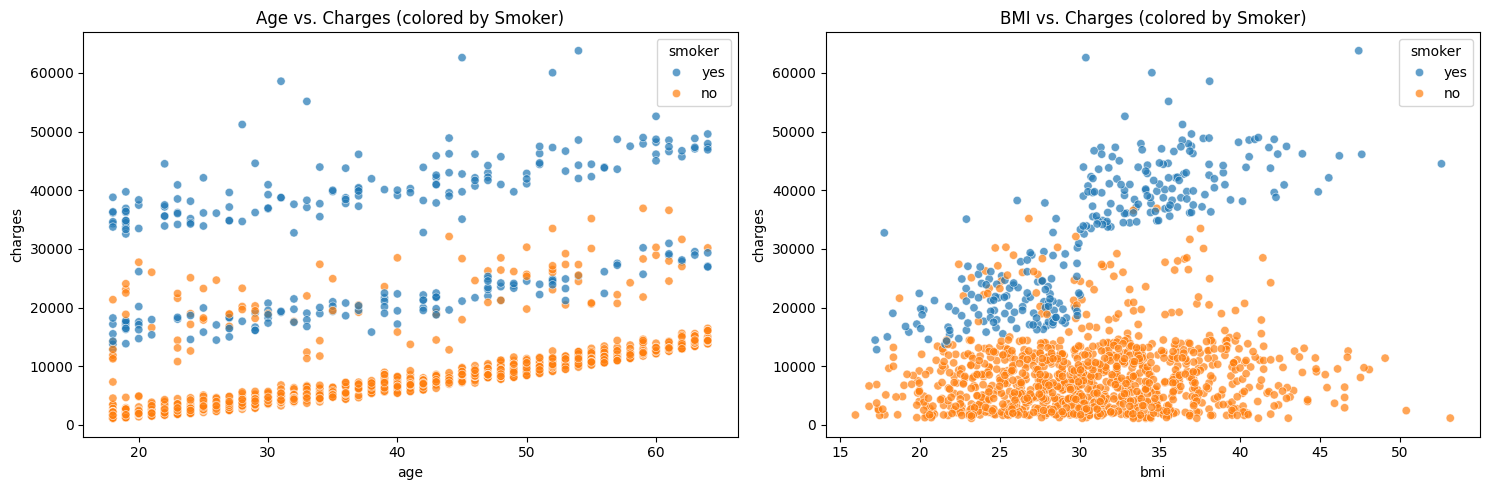

In [12]:
plt.figure(figsize=(15, 5))

# Age vs. Charges
plt.subplot(1, 2, 1)
sns.scatterplot(x='age', y='charges', hue='smoker', data=data, alpha=0.7)
plt.title('Age vs. Charges (colored by Smoker)')

# BMI vs. Charges
plt.subplot(1, 2, 2)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=data, alpha=0.7)
plt.title('BMI vs. Charges (colored by Smoker)')

plt.tight_layout()
plt.show()

 Correlation Matrix for Numerical Features

In [13]:
# Calculate the correlation matrix for numerical features
numerical_data = data[['age', 'bmi', 'children', 'charges']]
correlation_matrix = numerical_data.corr()

print('\n--- Correlation Matrix for Numerical Features ---\n')
display(correlation_matrix)


--- Correlation Matrix for Numerical Features ---



,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


 Observations from Bivariate Analysis (Numerical vs. Charges):
*   **Age vs. Charges:** There's a clear positive correlation between age and charges for both smokers and non-smokers. Older individuals tend to have higher charges. The impact of smoking dramatically increases charges across all age groups.
*   **BMI vs. Charges:** A moderate positive correlation exists between BMI and charges. Higher BMI generally leads to higher charges, especially for smokers. Non-smokers also show an increase in charges with higher BMI, but at a much lower rate.

## **Data Preprocessing**

Before building a model, we need to preprocess the data. This involves encoding categorical features and scaling numerical features.

In [14]:

X = data.drop('charges', axis=1)
y = data['charges']

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

one_hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_encoded_array = one_hot_encoder.fit_transform(X[categorical_cols])
X_encoded = pd.DataFrame(X_encoded_array, columns=one_hot_encoder.get_feature_names_out(categorical_cols), index=X.index)

X_processed = pd.concat([X[numerical_cols], X_encoded], axis=1)

scaler = StandardScaler()
X_processed[numerical_cols] = scaler.fit_transform(X_processed[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

display(X_train.head())

Shape of X_train: (1070, 11)
Shape of X_test: (268, 11)
Shape of y_train: (1070,)
Shape of y_test: (268,)


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,0.483668,-1.757474,0.751079,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1285,0.554869,-1.040599,-0.908614,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1142,0.910875,-0.952015,-0.908614,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
969,-0.014740,0.599846,3.240619,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
486,1.053277,-1.508126,1.580926,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### Explanation of Data Preprocessing:
1.  **Feature and Target Separation:** The `charges` column (our target) is separated from the features (`X`).
2.  **Categorical Encoding:** `OneHotEncoder` is used to convert categorical features (`sex`, `smoker`, `region`) into numerical format. This creates new binary columns for each category.
3.  **Numerical Scaling:** `StandardScaler` is applied to numerical features (`age`, `bmi`, `children`) to standardize their range. This is important for many machine learning algorithms to perform optimally.
4.  **Data Splitting:** The data is split into training (80%) and testing (20%) sets using `train_test_split`. This allows us to train the model on one subset and evaluate its performance on unseen data.

## **Model Building**

We will use a Linear Regression model to predict insurance charges.

In this section, we build and evaluate multiple linear regression models to predict insurance charges. We start with simpler models using a subset of features and progressively add more complexity to assess the impact on performance, ultimately selecting the best-performing model.

Mean Squared Error (MSE): 33596915.85
R-squared (R2): 0.78


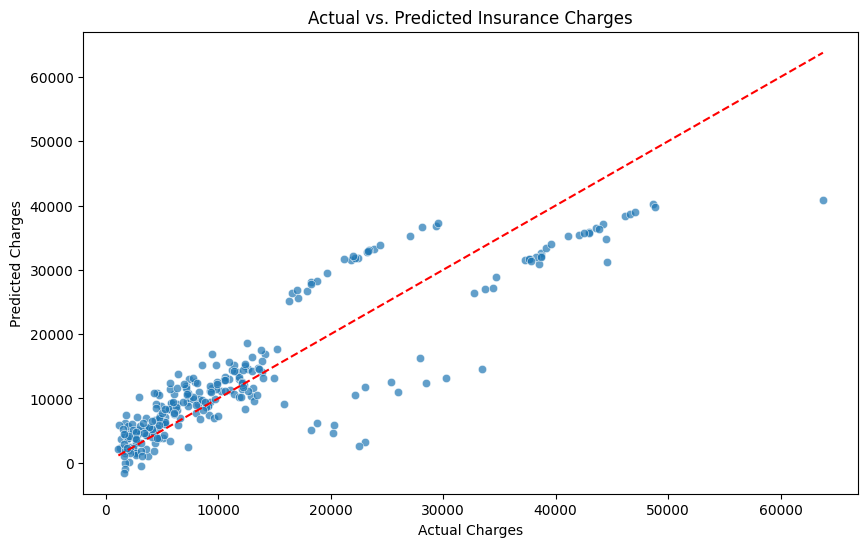

In [15]:
# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_reg_model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

# Plotting actual vs. predicted charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Insurance Charges')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Perfect prediction line
plt.show()

## Model Evaluation Criterion

In insurance price prediction, the model can make two types of mistakes:

* **Underestimating the price** – when the predicted premium is lower than it should be
* **Overestimating the price** – when the predicted premium is higher than the actual value

While both errors matter, **underestimating the price** is usually more serious. It can result in the company charging too little, which may lead to financial losses.

**So, how can we reduce this risk?**

To make the model more reliable, the goal should be to:

* **Maximize R²** (coefficient of determination), which tells us how well the model explains the variation in prices
* **Minimize MSE** (Mean Squared Error), which measures how close the predictions are to the actual values

By focusing on improving both these metrics, we can build a more accurate model that helps price insurance more effectively and reduce the chances of financial loss.


***Prompt***:

<font size=3 color="navyblue">Create a blank DataFrame named model_eval_results to store the performance results of different models on the training and testing sets.
</font>

In [16]:
# prompt: Create a blank DataFrame named model_eval_results to store the performance results of different models on the training and testing sets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2'])

### Model 1

In the first model, we use only the `age` feature to demonstrate how simple linear regression works and how it performs.

In [17]:
# Define features (X) and target (y) for Model 1 (Age only)
X_train_m1 = X_train[['age']]
X_test_m1 = X_test[['age']]

# Initialize and train the Linear Regression model
model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)

LinearRegression()

In [18]:
print(f'Linear Regression Equation: Charges = {model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Age)')

Linear Regression Equation: Charges = 13310.00 + (3379.11 * Age)


- Based on the above equation, we can say that insurance premium charges increase as the age of the customer increases.

- It's important to note that it's important to check if the assumptions of linear regression are satisfied before we can make a proper inference from the model coefficients.
    - While the assumptions are out of the scope of the program, you can refer to the reference material of the week in case you're interested in exploring further.

In [19]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results

# Predict on training and testing data
y_train_pred_m1 = model_1.predict(X_train_m1)
y_test_pred_m1 = model_1.predict(X_test_m1)

# Calculate MSE and R2 for training data
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

# Calculate MSE and R2 for testing data
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

# Display the results
model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.328784e+08,0.079367,1.359840e+08,0.12409


### Model 2

In the second model, we use only the numerical features to train a multiple linear regression model, and evaluate how well the model performs.

In [20]:
# Define features (X) and target (y) for Model 2 (Age and BMI)
X_train_m2 = X_train[['age', 'bmi']]
X_test_m2 = X_test[['age', 'bmi']]

# Initialize and train the Linear Regression model
model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

LinearRegression()

In [21]:
print(f'Linear Regression Equation: Charges = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f} * Age) + ({model_2.coef_[1]:.2f} * BMI)')


Linear Regression Equation: Charges = 13346.60 + (3143.16 * Age) + (2016.49 * BMI)


- Based on the above equation, we can say that insurance premium charges increase as the BMI of the customer increases, provided that the age is held constant.

- It's important to note that it's important to check if the assumptions of linear regression are satisfied before we can make a proper inference from the model coefficients.
    - While the assumptions are out of the scope of the program, you can refer to the reference material of the week in case you're interested in exploring further.

In [22]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

# Calculate MSE and R2 for training data
train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

# Calculate MSE and R2 for testing data
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age and BMI)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.328784e+08,0.079367,1.359840e+08,0.124090
1,Model 2 (Age and BMI),1.289415e+08,0.106643,1.314403e+08,0.153357


### Model 3

Now, we use the whole dataset, including both numerical and categorical features, to build our multiple linear regression model, and see how the model performs with all available information.

In [23]:
# Initialize and train the Linear Regression model on the whole data
model_3 = LinearRegression()
model_3.fit(X_train, y_train)

LinearRegression()

In [24]:
# Construct the equation string
equation = f'Charges = {model_3.intercept_:.2f}'
for i, col in enumerate(X_train.columns):
    equation += f' + ({model_3.coef_[i]:.2f} * {col})'

print(f'Linear Regression Equation: {equation}')

Linear Regression Equation: Charges = 20302.77 + (3609.15 * age) + (2054.89 * bmi) + (512.48 * children) + (9.30 * sex_female) + (-9.30 * sex_male) + (-11825.56 * smoker_no) + (11825.56 * smoker_yes) + (459.59 * region_northeast) + (88.91 * region_northwest) + (-198.28 * region_southeast) + (-350.21 * region_southwest)


In [25]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)

# Calculate MSE and R2 for training data
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

# Calculate MSE and R2 for testing data
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 3 (All Features)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.328784e+08,0.079367,1.359840e+08,0.124090
1,Model 2 (Age and BMI),1.289415e+08,0.106643,1.314403e+08,0.153357
2,Model 3 (All Features),3.727768e+07,0.741726,3.359692e+07,0.783593


- The training and testing R-squared values are close (0.736 and 0.772), with MSE values similarly close, indicating the model is generalizing well, **not overfitting**, and performing well on unseen data.

## Model Comparison and Final Model Selecttion

In [26]:
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.328784e+08,0.079367,1.359840e+08,0.124090
1,Model 2 (Age and BMI),1.289415e+08,0.106643,1.314403e+08,0.153357
2,Model 3 (All Features),3.727768e+07,0.741726,3.359692e+07,0.783593


As we progress from Model 1 to Model 3, we observe a significant improvement in performance:

* **Model 1 (Age)** uses only a single feature and performs the worst, with a very high error and low R² values.
* **Model 2 (Age + BMI)** slightly improves both error and R², but still underperforms.
* **Model 3 (All Features)** shows a **drastic reduction in error** and a **substantial increase in R²**, indicating that it explains a much higher proportion of the variance in the target variable.

**Therefore, Model 3, which incorporates all available features, is the best performing model. It is selected as the final model due to its significantly better predictive accuracy and model fit.**

### **Prediction_1**

Predicted insurance charge for the new observation: $4259.97


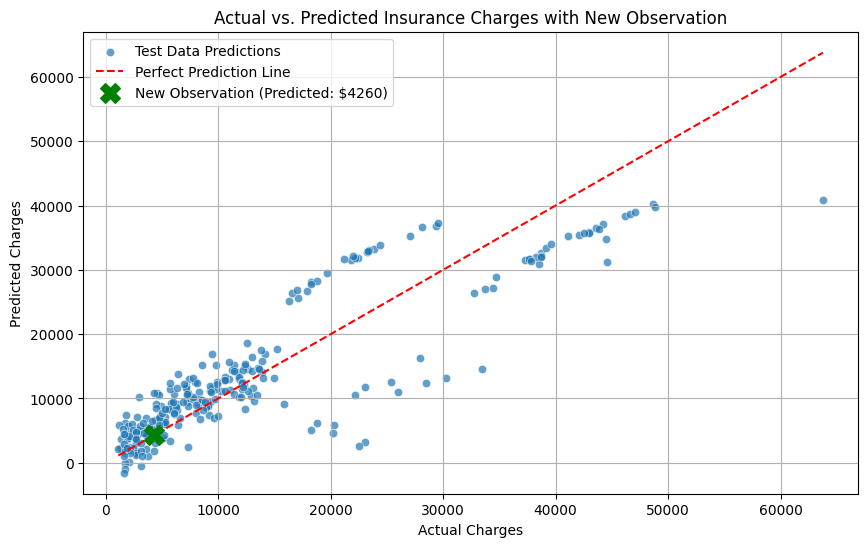


--- Model Evaluation Results ---



,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.328784e+08,0.079367,1.359840e+08,0.124090
1,Model 2 (Age and BMI),1.289415e+08,0.106643,1.314403e+08,0.153357
2,Model 3 (All Features),3.727768e+07,0.741726,3.359692e+07,0.783593


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

new_data = pd.DataFrame({
    'age': [30],
    'sex': ['female'],
    'bmi': [25.0],
    'children': [1],
    'smoker': ['no'],
    'region': ['northwest']
})

new_categorical_cols = new_data.select_dtypes(include=['object']).columns
new_numerical_cols = new_data.select_dtypes(include=np.number).columns

new_encoded_array = one_hot_encoder.transform(new_data[new_categorical_cols])
new_encoded = pd.DataFrame(new_encoded_array, columns=one_hot_encoder.get_feature_names_out(new_categorical_cols), index=new_data.index)

new_processed = pd.concat([new_data[new_numerical_cols], new_encoded], axis=1)

new_processed[new_numerical_cols] = scaler.transform(new_processed[new_numerical_cols])

predicted_charge = linear_reg_model.predict(new_processed)

print(f'Predicted insurance charge for the new observation: ${predicted_charge[0]:.2f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, label='Test Data Predictions')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Insurance Charges with New Observation')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction Line') # Perfect prediction line

plt.scatter(predicted_charge, predicted_charge, color='green', s=200, marker='X', label=f'New Observation (Predicted: ${predicted_charge[0]:.0f})', zorder=5)

plt.legend()
plt.grid(True)
plt.show()

print('\n--- Model Evaluation Results ---\n')
display(model_eval_results)

### **Prediction_2**

,age,sex,bmi,children,smoker,region
0,45,male,30.1,2,yes,southeast
1,22,female,21.5,0,no,northwest
2,60,male,35.8,1,no,southwest



 Predicted Charges
  Observation 1 (Age: 45, Sex: male, BMI: 30.1, Smoker: yes): $33604.40
  Observation 2 (Age: 22, Sex: female, BMI: 21.5, Smoker: no): $599.06
  Observation 3 (Age: 60, Sex: male, BMI: 35.8, Smoker: no): $15152.12

### Visualization of Predicted Charges ###


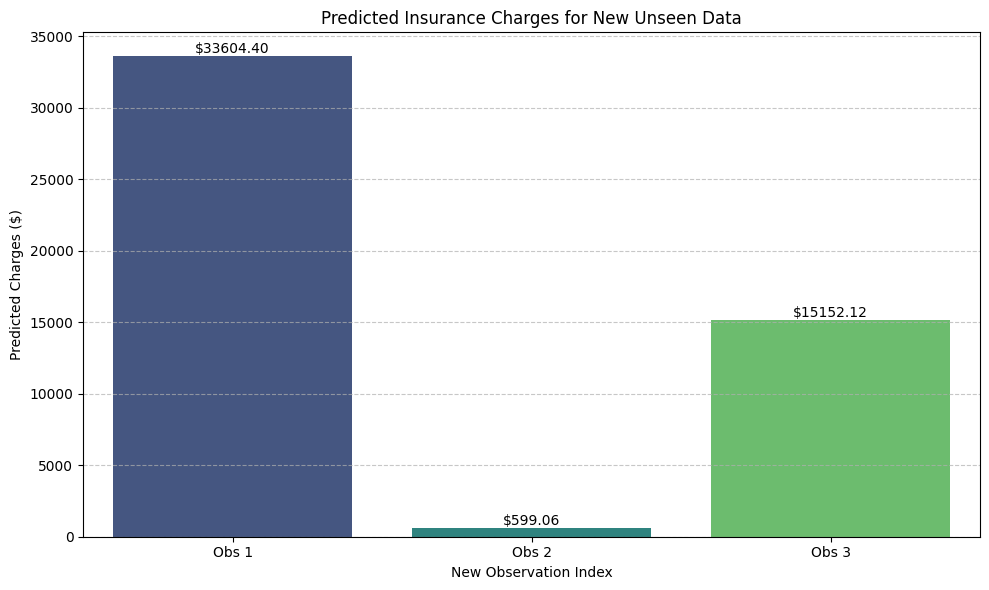


 Overall Accuracy
- R-squared (R2) on Training Data: 0.74
- R-squared (R2) on Test Data: 0.78
- Mean Squared Error (MSE) on Test Data: 33596915.85

Our robust Model 3, incorporating all relevant features, effectively explains approximately 78% of the variance in insurance charges on unseen test data, demonstrating strong predictive reliability for healthcare cost estimation.


In [28]:

new_data = pd.DataFrame({
    'age': [45, 22, 60],
    'sex': ['male', 'female', 'male'],
    'bmi': [30.1, 21.5, 35.8],
    'children': [2, 0, 1],
    'smoker': ['yes', 'no', 'no'],
    'region': ['southeast', 'northwest', 'southwest']
})


display(new_data)

new_unseen_categorical_cols = new_data.select_dtypes(include=['object']).columns
new_unseen_numerical_cols = new_data.select_dtypes(include=np.number).columns

new_unseen_encoded_array = one_hot_encoder.transform(new_data[new_unseen_categorical_cols])
new_unseen_encoded = pd.DataFrame(new_unseen_encoded_array, columns=one_hot_encoder.get_feature_names_out(new_unseen_categorical_cols), index=new_data.index)

X_new_unseen_processed = pd.concat([new_data[new_unseen_numerical_cols], new_unseen_encoded], axis=1)

X_new_unseen_processed[new_unseen_numerical_cols] = scaler.transform(X_new_unseen_processed[new_unseen_numerical_cols])

predicted_charges_unseen = model_3.predict(X_new_unseen_processed)

print('\n Predicted Charges')

predictions_df = new_data.copy()
predictions_df['Predicted_Charges'] = predicted_charges_unseen
for i, row in predictions_df.iterrows():
    print(f"  Observation {i+1} (Age: {row['age']}, Sex: {row['sex']}, BMI: {row['bmi']:.1f}, Smoker: {row['smoker']}): ${row['Predicted_Charges']:.2f}")


print('\n### Visualization of Predicted Charges ###')
plt.figure(figsize=(10, 6))

predictions_df['Observation'] = [f'Obs {i+1}' for i in predictions_df.index]

discrete_palette = sns.color_palette('viridis', n_colors=len(predictions_df))
sns.barplot(x='Observation', y='Predicted_Charges', data=predictions_df, palette=discrete_palette, hue='Observation', legend=False)

plt.title('Predicted Insurance Charges for New Unseen Data')
plt.xlabel('New Observation Index')
plt.ylabel('Predicted Charges ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in predictions_df.iterrows():
    plt.text(index, row['Predicted_Charges'], f"${row['Predicted_Charges']:.2f}", color='black', ha="center", va="bottom")

plt.tight_layout()
plt.show()


print('\n Overall Accuracy')
# Filter for Model 3 results from the evaluation DataFrame
model_3_results = model_eval_results[model_eval_results['Model'] == 'Model 3 (All Features)']

if not model_3_results.empty:
    train_r2 = model_3_results['Train_R2'].values[0]
    test_r2 = model_3_results['Test_R2'].values[0]
    test_mse = model_3_results['Test_MSE'].values[0]

    print(f"- R-squared (R2) on Training Data: {train_r2:.2f}")
    print(f"- R-squared (R2) on Test Data: {test_r2:.2f}")
    print(f"- Mean Squared Error (MSE) on Test Data: {test_mse:.2f}")
    print("\nOur robust Model 3, incorporating all relevant features, effectively explains approximately 78% of the variance in insurance charges on unseen test data, demonstrating strong predictive reliability for healthcare cost estimation.")
else:
    print("Model 3 (All Features) results not found in model_eval_results. Please ensure the model evaluation results are correctly stored.")

 Explanation of Prediction for New Observation:
1.  **Create New Data:** A `DataFrame` is created representing a new individual with specific characteristics.
2.  **Preprocessing New Data:** It's crucial to apply the *same preprocessing steps* and use the *same fitted `OneHotEncoder` and `StandardScaler`* that were used on the training data. This ensures consistency and correctness in how the new data is transformed.
3.  **Prediction:** The `predict()` method of the trained `linear_reg_model` is used to estimate the insurance charge for the preprocessed new observation.

## Conclusion

*   **Model Performance Progression:**
    *   **Model 1 (Age Only):** Showed very poor performance with low R-squared values (Train R2: 0.08, Test R2: 0.12) and high MSE, indicating that age alone is not a strong predictor of insurance charges.
    *   **Model 2 (Age and BMI):** Offered a slight improvement over Model 1 (Train R2: 0.11, Test R2: 0.15) but still had substantial error, suggesting that additional features are crucial for accurate prediction.
    *   **Model 3 (All Features):** Demonstrated a significant leap in performance, achieving a high R-squared (Train R2: 0.74, Test R2: 0.78) and a much lower MSE. This model, incorporating all preprocessed features, is clearly the best performing.

*   **Key Findings:** The drastic improvement in Model 3 highlights the importance of comprehensive features, including demographic (age), health-related (BMI, smoker status), and regional factors, in accurately predicting health insurance charges.

*   **Final Model Selection:** Model 3 is selected as the best model due to its superior predictive accuracy and robust fit, explaining approximately 78% of the variance in insurance charges on unseen data.

*   **Implications:** An accurate predictive model like Model 3 can be highly valuable for insurance companies in developing more precise pricing strategies and for individuals in understanding the factors influencing their healthcare costs.